# Setup

## Importing Libraries

In [56]:
import os
from dotenv import load_dotenv
from graphdatascience import GraphDataScience
import pandas as pd
import matplotlib.pyplot as plt

## Load and retreive neo4j variables from .env file

In [57]:
#Storing Neo4j connection details in variables
URI = "neo4j://127.0.0.1:7687"
USER = "neo4j"
PASSWORD = "researchgrade"
DB_NAME = "neo4j"

## Initialize the Graph Data Science client

In [58]:
gds = GraphDataScience(
    URI,
    auth=(USER, PASSWORD),
    database=DB_NAME
)
print("Connected to Neo4j GDS server version:", gds.version())

Connected to Neo4j GDS server version: 2.25.0


# Graph Projections

## Cleanup existing graph projection if it exists

In [59]:
dense_wcc_id = 2 

In [60]:
def drop_if_exists(graph_name: str):
    graphs = gds.graph.list()
    if "graphName" in graphs.columns and graph_name in graphs["graphName"].values:
        gds.graph.drop(graph_name)

## Directed Projections

### Predator to Prey Projection

In [61]:
# 1) Dense: predator -> prey  (reverse edges for "who points to prey" view)
drop_if_exists("dense_pred_to_prey")
G_dense_pred_to_prey, _ = gds.graph.project.cypher(
    "dense_pred_to_prey",
    f"""
    MATCH (s:Species)
    WHERE s.wccId = {dense_wcc_id}
    RETURN id(s) AS id
    """,
    f"""
    MATCH (prey:Species)-[:eaten_by]->(pred:Species)
    WHERE prey.wccId = {dense_wcc_id} AND pred.wccId = {dense_wcc_id}
    RETURN id(pred) AS source, id(prey) AS target
    """
)
print("Dense projections created: - dense_pred_to_prey")


Dense projections created: - dense_pred_to_prey


### Prey to Predator Projection

In [62]:
# 2) Dense: prey -> predator  (:eaten_by means prey -> predator)
drop_if_exists("dense_prey_to_pred")
G_dense_prey_to_pred, _ = gds.graph.project.cypher(
    "dense_prey_to_pred",
    f"""
    MATCH (s:Species)
    WHERE s.wccId = {dense_wcc_id}
    RETURN id(s) AS id
    """,
    f"""
    MATCH (prey:Species)-[:eaten_by]->(pred:Species)
    WHERE prey.wccId = {dense_wcc_id} AND pred.wccId = {dense_wcc_id}
    RETURN id(prey) AS source, id(pred) AS target
    """
)
print("Dense projections created: - dense_prey_to_pred")


Dense projections created: - dense_prey_to_pred


## Undirected Projection

In [63]:
# 3) Dense UNDIRECTED (strict): add reverse edges so it behaves undirected
drop_if_exists("dense_undirected")
G_dense_undirected, _ = gds.graph.project.cypher(
    "dense_undirected",
    f"""
    MATCH (s:Species)
    WHERE s.wccId = {dense_wcc_id}
    RETURN id(s) AS id
    """,
    f"""
    MATCH (a:Species)-[:eaten_by]->(b:Species)
    WHERE a.wccId = {dense_wcc_id} AND b.wccId = {dense_wcc_id}
    RETURN id(a) AS source, id(b) AS target
    UNION
    MATCH (a:Species)-[:eaten_by]->(b:Species)
    WHERE a.wccId = {dense_wcc_id} AND b.wccId = {dense_wcc_id}
    RETURN id(b) AS source, id(a) AS target
    """
)
print("Dense projections created: - dense_undirected")

Dense projections created: - dense_undirected


In [64]:
gds.graph.list()[["graphName","nodeCount","relationshipCount"]]

,graphName,nodeCount,relationshipCount
0,dense_pred_to_prey,829,984
1,dense_prey_to_pred,829,984
2,dense_undirected,829,1933
3,foodweb_rev,1876,1658
4,foodweb_und,1876,3316
5,foodweb,1876,1658


# Write properties in the graph

a. Total Degree centrality  
b. indegree centrality  
c. outdegree centrality  
d. Betweeness centrality  
e. Closeness centrality  
f. Eigenvector centrality  
g. Community (Louvian detection method)  
h. Strongly connected cycles  
i. Pagerank  

## Degree centrality

In [65]:
degree_dense = gds.degree.write(
    G_dense_undirected,
    writeProperty="totaldegree_dense"
)
print("Total degree centrality computed for dense undirected graph and written as 'totaldegree_dense'.\n")


Total degree centrality computed for dense undirected graph and written as 'totaldegree_dense'.



In [66]:
indegree_dense = gds.degree.write(
    G_dense_prey_to_pred,
    orientation='REVERSE',
    writeProperty='inDegree_dense'
)
print("Indegree centrality computed for dense prey-to-predator graph and written as 'inDegree_dense'.\n")


Indegree centrality computed for dense prey-to-predator graph and written as 'inDegree_dense'.



In [67]:
outdegree_dense = gds.degree.write(
    G_dense_prey_to_pred,
    orientation='NATURAL',
    writeProperty='outDegree_dense'
)
print("Outdegree centrality computed for dense prey-to-predator graph and written as 'outDegree_dense'.\n")

Outdegree centrality computed for dense prey-to-predator graph and written as 'outDegree_dense'.



## Betweeness Centrality

In [68]:
betweenness_und_dense = gds.betweenness.write(
    G_dense_undirected,
    writeProperty="betweenness_und_dense"
)
print("Betweenness centrality for dense undirected graph written as 'betweenness_und_dense'.\n")

Betweenness centrality for dense undirected graph written as 'betweenness_und_dense'.



In [69]:
betweenness_prey_dense = gds.betweenness.write(
    G_dense_prey_to_pred,
    writeProperty="betweenness_eaten_dense"
)
print("Betweenness centrality for dense prey-to-predator graph written as 'betweenness_eaten_dense'.\n")

Betweenness centrality for dense prey-to-predator graph written as 'betweenness_eaten_dense'.



## Closeness Centrality

In [70]:
closeness_und_dense = gds.closeness.write(
    G_dense_undirected,
    writeProperty="closeness_und_dense"
)
print("Closeness centrality computed for dense undirected graph and written as 'closeness_und_dense'.\n")


Closeness centrality computed for dense undirected graph and written as 'closeness_und_dense'.



In [71]:
closeness_prey_dense = gds.closeness.write(
    G_dense_prey_to_pred,
    writeProperty="closeness_eaten_dense"
)
print("Closeness centrality computed for dense prey-to-predator graph and written as 'closeness_eaten_dense'.\n")

Closeness centrality computed for dense prey-to-predator graph and written as 'closeness_eaten_dense'.



## Eigenvector centrality

In [72]:
eigenvector_prey_dense = gds.eigenvector.write(
    G_dense_prey_to_pred,
    writeProperty="eigenvector_dense"
)
print("Eigenvector centrality computed for dense prey-to-predator graph and written as 'eigenvector_dense'.\n")


Eigenvector centrality computed for dense prey-to-predator graph and written as 'eigenvector_dense'.



## Community Detection
Also writing the community size and coverage property

In [73]:
communities_dense = gds.louvain.write(
    G_dense_undirected,
    writeProperty="community_dense"
)
print("Communities detected for dense undirected graph (Louvain) and written as 'community_dense'.\n")


Communities detected for dense undirected graph (Louvain) and written as 'community_dense'.



In [74]:
# community_size within dense component
gds.run_cypher(f"""
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id} AND n.community_dense IS NOT NULL
WITH n.community_dense AS community, count(*) AS size
MATCH (m:Species)
WHERE m.wccId = {dense_wcc_id} AND m.community_dense = community
SET m.community_size_dense = size
""")
print("community_size_dense written to dense component nodes.\n")

# community_pct within dense component (coverage w.r.t. dense S, not full S)
gds.run_cypher(f"""
MATCH (x:Species)
WHERE x.wccId = {dense_wcc_id} AND x.community_dense IS NOT NULL
WITH count(x) AS S
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id} AND n.community_dense IS NOT NULL
WITH S, n.community_dense AS community, count(*) AS size, toFloat(count(*))/S AS pct
MATCH (m:Species)
WHERE m.wccId = {dense_wcc_id} AND m.community_dense = community
SET m.community_pct_dense = pct
""")
print("community_pct_dense written to dense component nodes.\n")


community_size_dense written to dense component nodes.

community_pct_dense written to dense component nodes.



## PageRank Scores

In [75]:
pagerank_pred_dense = gds.pageRank.write(
    G_dense_pred_to_prey,
    writeProperty="preyPageRank_dense"
)
print("PageRank written for dense predator-to-prey graph as 'preyPageRank_dense'.\n")

PageRank written for dense predator-to-prey graph as 'preyPageRank_dense'.



In [76]:
pagerank_prey_dense = gds.pageRank.write(
    G_dense_prey_to_pred,
    writeProperty="predPageRank_dense"
)
print("PageRank written for dense prey-to-predator graph as 'predPageRank_dense'.\n")

PageRank written for dense prey-to-predator graph as 'predPageRank_dense'.



# Analysis

## Relationship properties

In [77]:
# Analyze relationship properties (dense component only)
print("Analyzing relationship properties for 'eaten_by' (dense component):")
props_df_dense = gds.run_cypher(f"""
MATCH (a:Species)-[r:eaten_by]->(b:Species)
WHERE a.wccId = {dense_wcc_id} AND b.wccId = {dense_wcc_id}
UNWIND keys(r) AS k
RETURN k AS property, count(*) AS count
ORDER BY count DESC
""")
print(props_df_dense)


Analyzing relationship properties for 'eaten_by' (dense component):
                    property  count
0   predator_scientific_name    984
1       prey_scientific_name    984
2                observed_on    984
3                  time_zone    984
4                  image_url    984
5                        url    984
6         captive_cultivated    984
7            prey_agreements    984
8        predator_agreements    984
9                place_state    983
10             place_country    983
11                  latitude    983
12                 longitude    983
13              place_county    982
14                     place    980
15       positional_accuracy    853
16           type_of_feeding    671
17                place_town     73


## Metric statistics table

In [78]:
""" 
Builds and runs a Cypher query that aggregates basic statistics
(min, max, avg, count) for each computed network metric written to Species nodes
(DENSE COMPONENT ONLY).
Included metrics:
- totaldegree_dense (Degree)
- betweenness_und_dense (Betweenness_undirected)
- betweenness_eaten_dense (Betweenness Prey→Predator)
- closeness_und_dense (Closeness_undirected)
- closeness_eaten_dense (Closeness Prey→Predator)
- eigenvector_dense (EigenVector Prey→Predator)
- predPageRank_dense (PageRank Prey→Predator)
- preyPageRank_dense (PageRank Predator→Prey)
- community_size_dense (Community)
Result is stored in stats_df_dense; ensure dense metric properties have been written to the graph.
"""

stats_query_dense = f"""
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id}
RETURN 
    'Degree (dense)' as metric,
    min(n.totaldegree_dense) as min,
    max(n.totaldegree_dense) as max,
    avg(n.totaldegree_dense) as avg,
    count(n.totaldegree_dense) as count
UNION
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id}
RETURN 
    'Betweenness_undirected (dense)' as metric,
    min(n.betweenness_und_dense) as min,
    max(n.betweenness_und_dense) as max,
    avg(n.betweenness_und_dense) as avg,
    count(n.betweenness_und_dense) as count
UNION
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id}
RETURN 
    'Betweenness(Prey→Predator) (dense)' as metric,
    min(n.betweenness_eaten_dense) as min,
    max(n.betweenness_eaten_dense) as max,
    avg(n.betweenness_eaten_dense) as avg,
    count(n.betweenness_eaten_dense) as count
UNION
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id}
RETURN 
    'Closeness_undirected (dense)' as metric,
    min(n.closeness_und_dense) as min,
    max(n.closeness_und_dense) as max,
    avg(n.closeness_und_dense) as avg,
    count(n.closeness_und_dense) as count
UNION
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id}
RETURN 
    'Closeness(Prey→Predator) (dense)' as metric,
    min(n.closeness_eaten_dense) as min,
    max(n.closeness_eaten_dense) as max,
    avg(n.closeness_eaten_dense) as avg,
    count(n.closeness_eaten_dense) as count
UNION
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id}
RETURN 
    'EigenVector(Prey→Predator) (dense)' as metric,
    min(n.eigenvector_dense) as min,
    max(n.eigenvector_dense) as max,
    avg(n.eigenvector_dense) as avg,
    count(n.eigenvector_dense) as count
UNION
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id}
RETURN 
    'PageRank(Prey→Predator) (dense)' as metric,
    min(n.predPageRank_dense) as min,
    max(n.predPageRank_dense) as max,
    avg(n.predPageRank_dense) as avg,
    count(n.predPageRank_dense) as count
UNION
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id}
RETURN 
    'PageRank(Predator→Prey) (dense)' as metric,
    min(n.preyPageRank_dense) as min,
    max(n.preyPageRank_dense) as max,
    avg(n.preyPageRank_dense) as avg,
    count(n.preyPageRank_dense) as count
UNION
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id}
RETURN 
    'Community (dense)' as metric,
    min(n.community_size_dense) as min,
    max(n.community_size_dense) as max,
    avg(n.community_size_dense) as avg,
    count(n.community_size_dense) as count
"""

stats_df_dense = gds.run_cypher(stats_query_dense)

print("\nMetric Statistics (dense component):")
print(stats_df_dense)



Metric Statistics (dense component):
                               metric           min            max  \
0                      Degree (dense)  1.000000e+00      36.000000   
1      Betweenness_undirected (dense)  0.000000e+00  357885.550726   
2  Betweenness(Prey→Predator) (dense)  0.000000e+00     279.000000   
3        Closeness_undirected (dense)  5.457422e-02       0.145238   
4    Closeness(Prey→Predator) (dense)  0.000000e+00       1.000000   
5  EigenVector(Prey→Predator) (dense)  2.637736e-52       0.673066   
6     PageRank(Prey→Predator) (dense)  1.500000e-01       6.369510   
7     PageRank(Predator→Prey) (dense)  1.500000e-01       5.017443   
8                   Community (dense)  1.100000e+01      78.000000   

           avg  count  
0     2.331725    829  
1  7963.558504    829  
2     1.142340    829  
3     0.097413    829  
4     0.455403    829  
5     0.003294    829  
6     0.273760    829  
7     0.240284    829  
8    40.191797    829  


## Betweeness Centrality

In [79]:
"""
Retrieve top 10 species by undirected betweenness centrality (DENSE COMPONENT).
"""

betweeness_query_dense_und = f"""
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id} AND n.betweenness_und_dense IS NOT NULL
RETURN n.common_name as common_name,
       n.scientific_name as scientific_name,
       n.betweenness_und_dense as betweenness_Undirected,
       n.community_dense as community,
       n.wccId as wccId
ORDER BY betweenness_Undirected DESC
LIMIT 10
"""

betweeness_df_dense_und = gds.run_cypher(betweeness_query_dense_und)

print("\nTop 10 species by betweenness centrality for dense undirected graph:")
print(betweeness_df_dense_und)



Top 10 species by betweenness centrality for dense undirected graph:
            common_name                   scientific_name  \
0     Western Honey Bee                    Apis mellifera   
1         American Crow             Corvus brachyrhynchos   
2             Black Rat                     Rattus rattus   
3  Western Yellowjacket              Vespula pensylvanica   
4      Great Blue Heron                    Ardea herodias   
5     Coastal Resintree            Ozoroa obovata obovata   
6              Cape Fig                         Ficus sur   
7       Crescent Gunnel                      Pholis laeta   
8          Olympic Gull  Larus glaucescens × occidentalis   
9          Feral Pigeon           Columba livia domestica   

   betweenness_Undirected  community  wccId  
0           357885.550726        645      2  
1           205855.310110        396      2  
2           178375.923127        645      2  
3           177868.523127        645      2  
4           162627.088181   

In [80]:
"""
Retrieve top 10 species by directed betweenness centrality (prey→predator) (DENSE COMPONENT).
"""

betweeness_query_dense_dir = f"""
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id} AND n.betweenness_eaten_dense IS NOT NULL
RETURN n.common_name as common_name,
       n.scientific_name as scientific_name,
       n.betweenness_eaten_dense as betweenness_Prey2Pred,
       n.community_dense as community,
       n.wccId as wccId
ORDER BY betweenness_Prey2Pred DESC
LIMIT 10
"""

betweeness_df_dense_dir = gds.run_cypher(betweeness_query_dense_dir)

print("\nTop 10 species by betweenness centrality for dense directed graph (Prey -> Predator):")
print(betweeness_df_dense_dir)



Top 10 species by betweenness centrality for dense directed graph (Prey -> Predator):
             common_name              scientific_name  betweenness_Prey2Pred  \
0      Western Honey Bee               Apis mellifera                  279.0   
1              Siam weed          Chromolaena odorata                   84.0   
2   Western Yellowjacket         Vespula pensylvanica                   60.0   
3   Common Dotted Border  Mylothris agathina agathina                   52.0   
4          Dancing Amber             Telchinia serena                   35.0   
5       Eastern Pondhawk     Erythemis simplicicollis                   33.0   
6  American Red Squirrel      Tamiasciurus hudsonicus                   32.0   
7         American Robin           Turdus migratorius                   30.0   
8           European Eel            Anguilla anguilla                   24.0   
9                   None       Globimetula mweroensis                   24.0   

   community  wccId  
0        6

## Degree Centrality

In [81]:
"""
Top 10 species by total degree centrality (DENSE COMPONENT).
"""

degree_query_dense = f"""
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id} AND n.totaldegree_dense IS NOT NULL
RETURN n.common_name as common_name,
       n.scientific_name as scientific_name,
       n.totaldegree_dense as degree,
       n.community_dense as community
ORDER BY degree DESC
LIMIT 10
"""

degree_df_dense = gds.run_cypher(degree_query_dense)

print("\nTop 10 species by degree centrality (dense component):")
print(degree_df_dense)



Top 10 species by degree centrality (dense component):
             common_name                   scientific_name  degree  community
0      Western Honey Bee                    Apis mellifera    36.0        645
1       Great Blue Heron                    Ardea herodias    29.0        485
2        Common Wild Fig                      Ficus burkei    18.0        314
3        Yellow Justicia                    Justicia flava    15.0        377
4           Olympic Gull  Larus glaucescens × occidentalis    15.0        396
5                 Osprey                 Pandion haliaetus    15.0        485
6     American persimmon              Diospyros virginiana    15.0        169
7   Glaucous-winged Gull                 Larus glaucescens    14.0        396
8  Margined Calligrapher              Toxomerus marginatus    12.0        748
9  Eastern Gray Squirrel              Sciurus carolinensis    10.0        668


In [82]:
"""
Top species by indegree (dense component).
"""

indegree_query_dense = f"""
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id} AND n.inDegree_dense IS NOT NULL
RETURN n.common_name as common_name,
       n.scientific_name as scientific_name,
       n.inDegree_dense as Indegree,
       n.totaldegree_dense as Total_degree
ORDER BY Indegree DESC
"""

indegree_df_dense = gds.run_cypher(indegree_query_dense)

print("\nTop 10 species by indegree centrality (dense component):")
print(indegree_df_dense.head(10))



Top 10 species by indegree centrality (dense component):
             common_name                   scientific_name  Indegree  \
0      Western Honey Bee                    Apis mellifera      29.0   
1       Great Blue Heron                    Ardea herodias      29.0   
2           Olympic Gull  Larus glaucescens × occidentalis      15.0   
3                 Osprey                 Pandion haliaetus      15.0   
4   Glaucous-winged Gull                 Larus glaucescens      14.0   
5  Margined Calligrapher              Toxomerus marginatus      10.0   
6             Grey Heron                     Ardea cinerea       9.0   
7             Bald Eagle          Haliaeetus leucocephalus       9.0   
8          Cooper's Hawk                    Astur cooperii       8.0   
9          Black Vulture                  Coragyps atratus       8.0   

   Total_degree  
0          36.0  
1          29.0  
2          15.0  
3          15.0  
4          14.0  
5          12.0  
6           9.0  
7    

In [83]:
"""
Top species by outdegree (dense component).
"""

outdegree_query_dense = f"""
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id} AND n.outDegree_dense IS NOT NULL
RETURN n.common_name as common_name,
       n.scientific_name as scientific_name,
       n.outDegree_dense as Outdegree,
       n.totaldegree_dense as Total_degree
ORDER BY Outdegree DESC
"""

outdegree_df_dense = gds.run_cypher(outdegree_query_dense)

print("\nTop 10 species by outdegree centrality (dense component):")
print(outdegree_df_dense.head(10))



Top 10 species by outdegree centrality (dense component):
          common_name            scientific_name  Outdegree  Total_degree
0     Common Wild Fig               Ficus burkei       18.0          18.0
1  American persimmon       Diospyros virginiana       15.0          15.0
2     Yellow Justicia             Justicia flava       15.0          15.0
3   Western Honey Bee             Apis mellifera        9.0          36.0
4    creeping thistle            Cirsium arvense        9.0           9.0
5        Duiker-berry  Sclerocroton integerrimus        9.0           9.0
6      Natal Bluehaze     Tetraselago natalensis        9.0           9.0
7      Scrambling Fig          Ficus burtt-davyi        8.0           8.0
8            Cape Fig                  Ficus sur        8.0           8.0
9  Broom Sycamore Fig  Ficus sycomorus sycomorus        8.0           8.0


In [84]:
# Calculate total indegree and total outdegree (dense)
total_in_degree_dense = indegree_df_dense['Indegree'].sum()
total_out_degree_dense = outdegree_df_dense['Outdegree'].sum()

number_of_nodes_dense = len(indegree_df_dense)  # should equal dense node count if every node has indegree_dense

average_degree_dense = (total_in_degree_dense + total_out_degree_dense) / number_of_nodes_dense
average_indegree_dense = total_in_degree_dense / number_of_nodes_dense
average_outdegree_dense = total_out_degree_dense / number_of_nodes_dense

print(f"Average Degree (dense): {average_degree_dense}")
print(f"Average Indegree (dense): {average_indegree_dense}")
print(f"Average Outdegree (dense): {average_outdegree_dense}")


Average Degree (dense): 2.37394451145959
Average Indegree (dense): 1.186972255729795
Average Outdegree (dense): 1.186972255729795


## Closeness Centrality

In [85]:
"""
Species by undirected closeness centrality (DENSE COMPONENT).
"""

closeness_query_dense_und = f"""
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id} AND n.closeness_und_dense IS NOT NULL
RETURN n.common_name as common_name,
       n.scientific_name as scientific_name,
       n.closeness_und_dense as Closeness_undirected,
       n.community_dense as community
ORDER BY Closeness_undirected DESC
"""

closeness_df_dense_und = gds.run_cypher(closeness_query_dense_und)

print("\nSpecies by closeness centrality on dense undirected graph:")
print(closeness_df_dense_und.head(10))



Species by closeness centrality on dense undirected graph:
              common_name        scientific_name  Closeness_undirected  \
0       Western Honey Bee         Apis mellifera              0.145238   
1           American Crow  Corvus brachyrhynchos              0.142390   
2    Western Yellowjacket   Vespula pensylvanica              0.141490   
3               Black Rat          Rattus rattus              0.139723   
4        Great Blue Heron         Ardea herodias              0.138693   
5        common dandelion   Taraxacum officinale              0.137222   
6         Crescent Gunnel           Pholis laeta              0.137154   
7  Immigrant Pavement Ant  Tetramorium immigrans              0.135693   
8          Western Earwig      Forficula dentata              0.134744   
9           Red Rock Crab       Cancer productus              0.132544   

   community  
0        645  
1        396  
2        645  
3        645  
4        485  
5        790  
6        396  
7    

In [86]:
"""
Species by directed closeness centrality (prey -> predator) (DENSE COMPONENT).
"""
# The closeness for directed graph (prey -> predator) is 1 for 314 species.

closeness_query_dense_dir = f"""
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id} AND n.closeness_eaten_dense IS NOT NULL
RETURN n.common_name as common_name,
       n.scientific_name as scientific_name,
       n.closeness_eaten_dense as Closeness_Prey2Pred,
       n.community_dense as community
ORDER BY Closeness_Prey2Pred DESC
Limit 315
"""

closeness_df_dense_dir = gds.run_cypher(closeness_query_dense_dir)

print("\nSpecies by closeness centrality on dense directed(Prey -> Predator) graph:")
print(closeness_df_dense_dir)



Species by closeness centrality on dense directed(Prey -> Predator) graph:
                     common_name                   scientific_name  \
0                  Laughing Gull             Leucophaeus atricilla   
1                Six-spot Burnet              Zygaena filipendulae   
2                     Lobed Beak                    Libythea laius   
3           Green Cape White-eye                  Zosterops virens   
4            California Sea Lion            Zalophus californianus   
..                           ...                               ...   
310                Squacco Heron                 Ardeola ralloides   
311    Common Zebra Blue Complex                Leptotes pirithous   
312             Great Blue Heron                    Ardea herodias   
313                 Olympic Gull  Larus glaucescens × occidentalis   
314  Southern Dark-capped Bulbul               Pycnonotus barbatus   

     Closeness_Prey2Pred  community  
0               1.000000        398  
1      

## Long chains using APOC path expansion

In [87]:


# This Cypher query is designed to find long chains of relationships in the DENSE COMPONENT only.
# Specifically, it identifies paths in the graph where nodes are connected by the 'eaten_by' relationship.
"""
Find long trophic chains (paths following 'eaten_by' relationships) using APOC path expansion (DENSE ONLY).

What this code does:
- Restricts starting nodes to the dense component (s.wccId = dense_wcc_id).
- Expands directed paths following incoming 'eaten_by' links (relationshipFilter: '<eaten_by').
- Ensures all nodes in the returned path remain inside the dense component.
- Uses NODE_GLOBAL uniqueness to avoid revisiting nodes within a path and reduce trivial cycles.
- Returns chains as ordered scientific names and their lengths so the longest food chains can be inspected.

Ecological rationale / benefits:
- Same as whole graph, but focused on the main connected subweb (removes noisy peripheral fragments).
"""

long_chain_dense = f"""
MATCH (s:Species)
WHERE s.wccId = {dense_wcc_id}
CALL apoc.path.expandConfig(s, {{
  relationshipFilter: '<eaten_by',
  minLevel: 1,
  maxLevel: 50,
  uniqueness: 'NODE_GLOBAL',
  bfs: false,
  limit: 100000
}}) YIELD path
// keep only paths fully inside dense component
WHERE all(n IN nodes(path) WHERE n.wccId = {dense_wcc_id})
WITH path, length(path)+1 AS len
RETURN apoc.text.join([n IN nodes(path) | n.scientific_name], ' -> ') AS chain, len 
ORDER BY len DESC
"""

long_chain_df_dense = gds.run_cypher(long_chain_dense)

print("\nTop 10 longest food chains found (dense component):")
print(long_chain_df_dense.head(10))

long_chain_df_dense.to_csv("Data/long_food_chains_dense.csv", index=False)



Top 10 longest food chains found (dense component):
                                               chain  len
0  Pantherophis spiloides -> Strix varia -> Tamia...    6
1  Pantherophis spiloides -> Strix varia -> Tamia...    5
2  Pantherophis spiloides -> Strix varia -> Tamia...    5
3  Pantherophis spiloides -> Strix varia -> Tamia...    5
4  Pantherophis spiloides -> Strix varia -> Tamia...    5
5  Pica hudsonia -> Tamiasciurus hudsonicus -> Tu...    5
6  Piranga olivacea -> Vespa crabro -> Promachus ...    5
7  Piranga olivacea -> Vespa crabro -> Promachus ...    5
8  Piranga olivacea -> Vespa crabro -> Promachus ...    5
9  Spinus tristis tristis -> Tamiasciurus hudsoni...    5


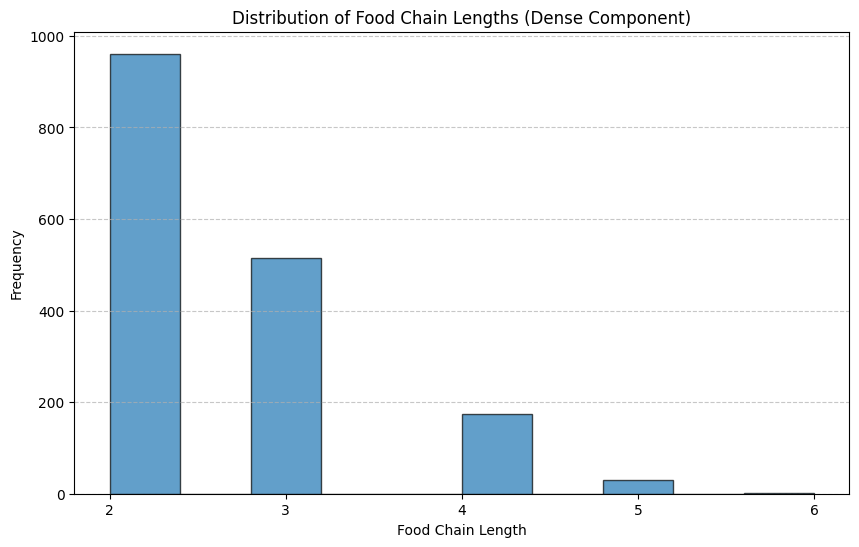

In [88]:
# Plot the distribution of food chain lengths (dense component)
plt.figure(figsize=(10, 6))
long_chain_df_dense['len'].plot(kind='hist', bins=10, edgecolor='black', alpha=0.7)
plt.title('Distribution of Food Chain Lengths (Dense Component)')
plt.xlabel('Food Chain Length')
plt.xticks(range(int(long_chain_df_dense['len'].min()), int(long_chain_df_dense['len'].max()) + 1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Connectance

In [89]:
# Cypher query to calculate connectance (DENSE COMPONENT)
"""
Compute connectance (dense component only): (actual directed trophic links) / (possible directed links without self-loops).

What the code does:
- Counts distinct Species nodes in dense component (S).
- Counts all 'eaten_by' relationships where both endpoints are in dense component (L).
- Computes possible directed links as S*(S-1) (no self-loops).
- Returns actual_links, possible_links, and connectance ratio.

Ecological perspective / why this helps:
- Connectance quantifies interaction density inside the main connected subweb.
- Higher connectance indicates more trophic coupling within the dense component.
- Useful for comparing the dense “core” vs the full graph (core may be denser if periphery is fragmented).
"""


connectance_query_dense = f"""
// Dense Species count (S)
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id}
WITH collect(id(n)) AS denseIds, count(n) AS S

// Dense edge count (L) using only those nodes
MATCH (a:Species)-[r:eaten_by]->(b:Species)
WHERE id(a) IN denseIds AND id(b) IN denseIds AND a <> b
WITH S, count(r) AS L
RETURN L AS actual_links,
       S*(S-1) AS possible_links,
       toFloat(L)/(S*(S-1)) AS connectance;
"""

connectance_df_dense = gds.run_cypher(connectance_query_dense)
print("\nConnectance of the dense component:")
print(connectance_df_dense)




Connectance of the dense component:
   actual_links  possible_links  connectance
0           967          686412     0.001409


## Clustering Co-efficent

In [90]:


# Cypher query to calculate average clustering coefficient (unordered neighbor pairs) (DENSE ONLY)
"""
Compute average clustering coefficient for the dense component only (unordered neighbor pairs).

What the code does:
- Restricts focal nodes n to the dense component (n.wccId = dense_wcc_id).
- Collects neighbors via undirected 'eaten_by' links, also restricted to dense component.
- For nodes with k > 1 neighbors, enumerates unordered unique neighbor pairs (id(a) < id(b)).
- Counts how many of those neighbor pairs are connected (triangle closure), restricted to dense component.
- Computes local clustering per node and returns the average across dense nodes.

Ecological interpretation:
- Measures local cohesion / triangle closure inside the dense “core” subweb.
"""

clustering_query_dense = f"""
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id}
OPTIONAL MATCH (n)-[:eaten_by]-(nbr:Species)
WHERE nbr.wccId = {dense_wcc_id}
WITH n, collect(DISTINCT nbr) AS N, size(collect(DISTINCT nbr)) AS k
WHERE k > 1
UNWIND N AS a
UNWIND N AS b
WITH n, k, a, b
WHERE id(a) < id(b)
MATCH (a:Species)-[:eaten_by]-(b:Species)
WHERE a.wccId = {dense_wcc_id} AND b.wccId = {dense_wcc_id}
WITH n, k, count(DISTINCT [id(a), id(b)]) AS unordered_connected_pairs
RETURN avg( (2.0 * unordered_connected_pairs) / (k * (k - 1)) ) AS average_clustering
"""

clustering_df_dense = gds.run_cypher(clustering_query_dense)

print("\nAverage Clustering Coefficient (dense component only):")
print(clustering_df_dense)



Average Clustering Coefficient (dense component only):
   average_clustering
0             0.43951


## Community Stats

In [91]:
"""
Builds a simple community-size table and orders communities by size (DENSE COMPONENT).

What it does:
- Aggregates dense Species nodes by their 'community_dense' id and counts members per community.
- Returns a (community, size) table sorted descending so the largest communities appear first.

How this helps:
- Quickly identifies the largest modules/trophic compartments inside the dense component.
"""

community_stats_query_dense = f"""
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id} AND n.community_dense IS NOT NULL
WITH n.community_dense AS community, count(*) AS size
RETURN community, size
ORDER BY size DESC
"""

community_df_dense = gds.run_cypher(community_stats_query_dense)
print("\nTop largest communities (dense component):")
print(community_df_dense)



Top largest communities (dense component):
    community  size
0         485    78
1         772    57
2         377    52
3         314    46
4         285    44
5         733    44
6         645    41
7         790    40
8         169    38
9         748    37
10        315    36
11        396    36
12        398    35
13        799    31
14        305    29
15        820    25
16        256    24
17        668    20
18        571    20
19        648    19
20        559    18
21        379    18
22        432    15
23        703    15
24        509    11


In [92]:
"""
Community stats summary (DENSE COMPONENT).

What the code does:
- Builds (community, size) for dense component.
- Computes num communities, mean, median, min, max, stddev.
"""

community_stats_query_all_dense = f"""
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id} AND n.community_dense IS NOT NULL
WITH n.community_dense AS community, count(*) AS size

WITH collect({{community: community, size: size}}) AS comms
WITH comms, [c IN comms | c.size] AS sizes

UNWIND sizes AS s
WITH comms, sizes, s
RETURN
  comms                                AS community_table,
  size(comms)                          AS num_communities,
  avg(s)                               AS mean_size,
  percentileCont(s, 0.5)               AS median_size,
  max(s)                               AS largest_size,
  min(s)                               AS smallest_size,
  sqrt(
      (avg(s*s) - avg(s)*avg(s)) *
      size(comms) /
      (CASE WHEN size(comms) > 1 THEN (size(comms) - 1) ELSE 1 END)
  ) AS size_stddev
"""

community_df_all_dense = gds.run_cypher(community_stats_query_all_dense)
print("\nCommunity Statistics (dense component, incl. singletons):")
print(community_df_all_dense)



Community Statistics (dense component, incl. singletons):
                                     community_table  num_communities  \
0  [{'size': 78, 'community': 485}, {'size': 44, ...               25   

   mean_size  median_size  largest_size  smallest_size  size_stddev  
0      33.16           35            78             11    15.584929  


In [93]:
"""
Compute and display the community-size distribution and its cumulative coverage (DENSE COMPONENT).
"""

community_size_distribution_query_dense = f"""
// Total number of Species in dense component (S)
MATCH (x:Species)
WHERE x.wccId = {dense_wcc_id} AND x.community_dense IS NOT NULL
WITH count(x) AS S

// Count communities and their sizes (include singletons)
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id} AND n.community_dense IS NOT NULL
WITH S, n.community_dense AS community, count(*) AS size
WITH S, size, count(*) AS num_communities
WITH
  S,
  size,
  num_communities,
  (size * num_communities) AS species_in_those_comms
RETURN
  size,
  num_communities,
  species_in_those_comms,
  toFloat(species_in_those_comms) / S AS pct_of_all_species
ORDER BY size DESC
"""

dist_df_dense = gds.run_cypher(community_size_distribution_query_dense)
print("\nCommunity size distribution (dense component, by size):")
dist_df_dense['cumulative_pct'] = dist_df_dense['pct_of_all_species'].cumsum()
print(dist_df_dense)



Community size distribution (dense component, by size):
    size  num_communities  species_in_those_comms  pct_of_all_species  \
0     78                1                      78            0.094089   
1     57                1                      57            0.068758   
2     52                1                      52            0.062726   
3     46                1                      46            0.055489   
4     44                2                      88            0.106152   
5     41                1                      41            0.049457   
6     40                1                      40            0.048251   
7     38                1                      38            0.045838   
8     37                1                      37            0.044632   
9     36                2                      72            0.086852   
10    35                1                      35            0.042220   
11    31                1                      31            0.0373

## Eigenvector centrality

In [94]:
# We calculated eigenvector centrality based on prey to predator graph (DENSE COMPONENT)
"""
Retrieve and display the top species by eigenvector centrality (dense component only).
"""

eigenvector_query_dense = f"""
MATCH (n:Species)
WHERE n.wccId = {dense_wcc_id} AND n.eigenvector_dense IS NOT NULL
RETURN n.common_name as common_name,
       n.scientific_name as scientific_name,
       n.eigenvector_dense as eigenvector,
       n.community_dense as community
ORDER BY eigenvector DESC
LIMIT 10
"""

eigenvector_df_dense = gds.run_cypher(eigenvector_query_dense)

print("\nTop 10 species by eigenvector centrality (dense component):")
print(eigenvector_df_dense)



Top 10 species by eigenvector centrality (dense component):
                common_name              scientific_name  eigenvector  \
0                 Siam weed          Chromolaena odorata     0.673066   
1      Common Dotted Border  Mylothris agathina agathina     0.384549   
2                      None             Delta fenestrale     0.295177   
3      African Common White     Belenois creona severina     0.295177   
4             Dancing Amber             Telchinia serena     0.295177   
5                   Dodgers                  Afrogegenes     0.295177   
6                 Fever Tea              Lippia javanica     0.203788   
7  White-banded Crab Spider      Misumenoides formosipes     0.059990   
8         Western Honey Bee               Apis mellifera     0.037095   
9      Banded Garden Spider          Argiope trifasciata     0.022926   

   community  
0        377  
1        377  
2        377  
3        377  
4        377  
5        377  
6        377  
7        645  


## PageRank

In [95]:
"""
Top food sources (preyPageRank) in dense component.
"""

pagerank_query_dense = f"""
MATCH (s:Species)
WHERE s.wccId = {dense_wcc_id} AND s.preyPageRank_dense IS NOT NULL
RETURN s.scientific_name AS prey,
       s.common_name AS common_name,
       s.preyPageRank_dense AS preyPageRank_dense
ORDER BY preyPageRank_dense DESC
LIMIT 10
"""

pagerank_dense = gds.run_cypher(pagerank_query_dense)

print("\nTop 10 species by pagerank (Important food sources) (dense component):")
print(pagerank_dense)



Top 10 species by pagerank (Important food sources) (dense component):
                        prey          common_name  preyPageRank_dense
0            Trema orientale       Oriental trema            5.017443
1               Rhus typhina       staghorn sumac            4.623383
2         Sylvicapra grimmia          Bush Duiker            1.822688
3       Diospyros virginiana   American persimmon            1.813344
4               Ficus burkei      Common Wild Fig            1.595304
5             Justicia flava      Yellow Justicia            1.353820
6   Erythemis simplicicollis     Eastern Pondhawk            1.193250
7     Asclepias fascicularis  narrowleaf milkweed            1.136149
8            Cirsium arvense     creeping thistle            1.078764
9  Sclerocroton integerrimus         Duiker-berry            0.969188


In [96]:
dense_wcc_id = 2  # <-- replace with your dense component wccId

"""
PageRank (predPageRank_dense) : (DENSE COMPONENT)

- Context:
    predPageRank_dense was computed on the dense prey -> predator projection (edges point from prey to predators).
    In that orientation, PageRank flows from prey to predators, so predators receive score from their prey.

- What a high predPageRank_dense means:
    * Predators with many prey, or with prey that themselves are well-connected/important, accumulate high predPageRank_dense.
    * Such predators act as integrators of energy/resources across the dense food web and can be influential consumers.
    * They may regulate multiple prey populations and mediate indirect effects across dense communities.

- Practical uses:
    * Identify influential consumers (candidate keystone predators) inside the dense component for monitoring, management, or further study.
    * Prioritize predators whose removal or decline could disproportionately alter energy flow or trigger cascades within the main connected subweb.
    * Combine predPageRank_dense with abundance, interaction strength, degree, and community context for robust inference.
"""

pagerank_query_dense = f"""
MATCH (s:Species)
WHERE s.wccId = {dense_wcc_id} AND s.predPageRank_dense IS NOT NULL
RETURN s.scientific_name AS predator,
       s.common_name AS common_name,
       s.predPageRank_dense AS predPageRank_dense,
       s.community_dense AS community
ORDER BY predPageRank_dense DESC
LIMIT 10
"""

pagerank_dense = gds.run_cypher(pagerank_query_dense)

print("\nTop 10 species by pagerank (Influential consumers) (dense component):")
print(pagerank_dense)



Top 10 species by pagerank (Influential consumers) (dense component):
                           predator                  common_name  \
0                 Pandion haliaetus                       Osprey   
1                    Apis mellifera            Western Honey Bee   
2               Chromolaena odorata                    Siam weed   
3           Misumenoides formosipes     White-banded Crab Spider   
4                Bucephala clangula             Common Goldeneye   
5          Euthyrhynchus floridanus  Florida Predatory Stink Bug   
6                    Ardea herodias             Great Blue Heron   
7                      Larus fuscus     Lesser Black-backed Gull   
8       Mylothris agathina agathina         Common Dotted Border   
9  Larus glaucescens × occidentalis                 Olympic Gull   

   predPageRank_dense  community  
0            6.369510        485  
1            3.436008        645  
2            3.076677        377  
3            3.001761        645  
4    